In [2]:
# STEP 1: Load dataset (MNIST) — no manual download needed
import tensorflow as tf
import numpy as np

print("TensorFlow:", tf.__version__)

# Load MNIST (Keras fetches it automatically on first use)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Loaded MNIST!")
print("x_train shape:", x_train.shape, "| dtype:", x_train.dtype)
print("y_train shape:", y_train.shape, "| dtype:", y_train.dtype)
print("x_test shape:", x_test.shape, " | y_test shape:", y_test.shape)


TensorFlow: 2.16.2
Loaded MNIST!
x_train shape: (60000, 28, 28) | dtype: uint8
y_train shape: (60000,) | dtype: uint8
x_test shape: (10000, 28, 28)  | y_test shape: (10000,)


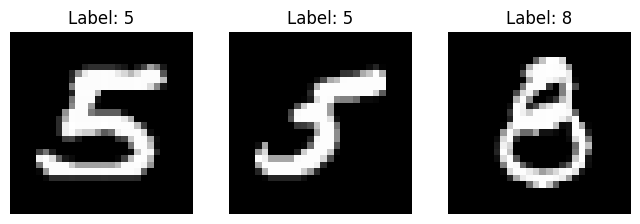

In [3]:
# STEP 2: Visual sanity check — show 3 random images

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
for i in range(3):
    idx = np.random.randint(0, x_train.shape[0])
    plt.subplot(1, 3, i+1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(f"Label: {y_train[idx]}")
    plt.axis("off")
plt.show()


In [4]:
# STEP 3: Dataset summary & class distribution

import pandas as pd

# Number of samples
print("Training samples:", x_train.shape[0])
print("Test samples:", x_test.shape[0])

Training samples: 60000
Test samples: 10000


In [5]:
# Image dimensions
print("Image shape:", x_train.shape[1:], "(Height, Width)")

Image shape: (28, 28) (Height, Width)


In [6]:
# Unique classes
classes = np.unique(y_train)
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


In [7]:
# Class distribution in training data
train_counts = pd.Series(y_train).value_counts().sort_index()
print("\nClass distribution (train):")
print(train_counts)


Class distribution (train):
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


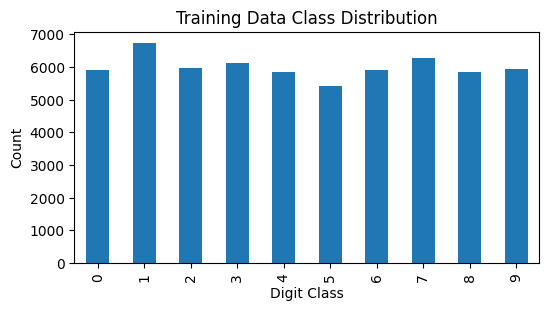

In [8]:
# Plot class distribution
train_counts.plot(kind="bar", figsize=(6,3))
plt.xlabel("Digit Class")
plt.ylabel("Count")
plt.title("Training Data Class Distribution")
plt.show()

In [9]:
# STEP 4: Split training set into train & validation

from sklearn.model_selection import train_test_split

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print("Train final shape:", x_train_final.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)


Train final shape: (54000, 28, 28)
Validation shape: (6000, 28, 28)
Test shape: (10000, 28, 28)


In [10]:
# STEP 5: Preprocessing

# Normalize pixel values to 0-1
x_train_final = x_train_final.astype("float32") / 255.0
x_val = x_val.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [11]:
# Add channel dimension
x_train_final = np.expand_dims(x_train_final, -1)
x_val = np.expand_dims(x_val, -1)
x_test = np.expand_dims(x_test, -1)

In [12]:
print("Train shape:", x_train_final.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)
print("Pixel range after normalization:", x_train_final.min(), "to", x_train_final.max())

Train shape: (54000, 28, 28, 1)
Validation shape: (6000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)
Pixel range after normalization: 0.0 to 1.0


In [13]:
# STEP 6: Build CNN architecture
from tensorflow.keras import layers, models

model = models.Sequential([
    # 1️⃣ First Convolution Layer
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Output shape: (batch, 26, 26, 32) because:
    # - 3x3 kernel reduces width & height by 2 each (no padding)
    # - 32 filters means output has 32 channels

    # 2️⃣ First MaxPooling Layer
    layers.MaxPooling2D((2, 2)),
    # Output shape: (batch, 13, 13, 32) — pooling halves height & width

    # 3️⃣ Second Convolution Layer
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Output shape: (batch, 11, 11, 64)

    # 4️⃣ Second MaxPooling Layer
    layers.MaxPooling2D((2, 2)),
    # Output shape: (batch, 5, 5, 64)

    # 5️⃣ Flatten — turn 3D feature maps into 1D vector
    layers.Flatten(),
    # Output shape: (batch, 1600) because 5*5*64 = 1600

    # 6️⃣ Dense Layer
    layers.Dense(64, activation='relu'),
    # Output shape: (batch, 64)

    # 7️⃣ Output Layer — 10 neurons (digits 0–9)
    layers.Dense(10, activation='softmax')
])

# Show model summary
model.summary()


/opt/anaconda3/envs/cnn101/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-17 17:25:38.258877: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-08-17 17:25:38.258920: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-08-17 17:25:38.258927: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-08-17 17:25:38.259114: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-17 17:25:38.259128: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.c

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# STEP 7: Compile the model (choose how learning happens)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# STEP 8: Set up training helpers (callbacks) 
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
ckpt = tf.keras.callbacks.ModelCheckpoint(
    'best_mnist_cnn.keras', monitor='val_loss', save_best_only=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)

In [16]:
# ===== STEP 9: Train the model =====
history = model.fit(
    x_train_final, y_train_final,
    validation_data=(x_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, ckpt, reduce_lr],
    verbose=1
)

Epoch 1/15


2025-08-17 17:26:48.625710: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9359 - loss: 0.2089 - val_accuracy: 0.9742 - val_loss: 0.0885 - learning_rate: 0.0010
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9796 - loss: 0.0666 - val_accuracy: 0.9777 - val_loss: 0.0739 - learning_rate: 0.0010
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9844 - loss: 0.0519 - val_accuracy: 0.9818 - val_loss: 0.0719 - learning_rate: 0.0010
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9848 - loss: 0.0542 - val_accuracy: 0.9753 - val_loss: 0.0967 - learning_rate: 0.0010
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9859 - loss: 0.0555 - val_accuracy: 0.9818 - val_loss: 0.0928 - learning_rate: 0.0010
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9911 - loss: 0.0390 - val_accuracy: 0.9828 - val_loss: 0.1148 - learning_rate: 5.0000e-04


In [17]:
#STEP 10: Final evaluation on the untouched test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

Test loss: 0.0521 | Test accuracy: 0.9843


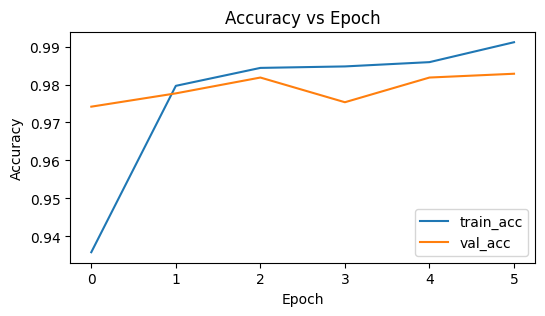

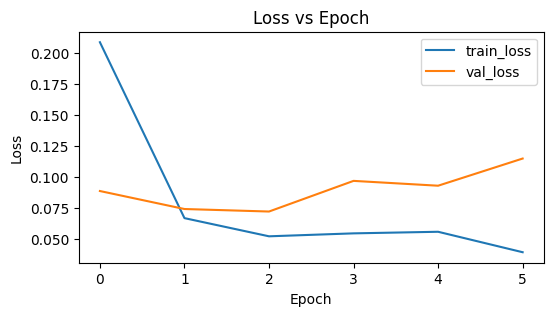

In [18]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(6,3))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy vs Epoch'); plt.legend(); plt.show()

# Loss
plt.figure(figsize=(6,3))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss vs Epoch'); plt.legend(); plt.show()
